In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import src.visualization
importlib.reload(src.visualization)
from src.visualization import plot_pca, plot_umap, plot_tsne, plot_pca_dark, plot_umap_dark, plot_tsne_dark

In [8]:
data = np.load("../../features/data-embeddings-cml-small_spearman.npz", allow_pickle=True)
X = data["X"]
y = data["y"]
M = data["M"].astype(int)
T = data["T"].astype(int)

# --- filters (set to None to disable) ---
M_filter = None
classes = [
            "brownian-defect", 
            "chaotic-traveling-wave", "sti-ii",
            "defect-turbulence", 
            "fdstc", "frozen-chaos", "pattern-selection", 
            "sti-i",  "travelling-wave", "travelling-wave-kaneko67",
            ]

mask = np.ones(len(y), dtype=bool)
if M_filter is not None:
    mask &= M == M_filter
if classes is not None:
    mask &= np.isin(y, classes)
X, y, M, T = X[mask], y[mask], M[mask], T[mask]

meta_df = pd.DataFrame({"mts_class": y, "M": M, "T": T})
print(f"X: {X.shape}, classes: {np.unique(y).tolist()}")

X: (720, 17339), classes: ['brownian-defect', 'chaotic-traveling-wave', 'defect-turbulence', 'fdstc', 'frozen-chaos', 'pattern-selection', 'sti-i', 'sti-ii']


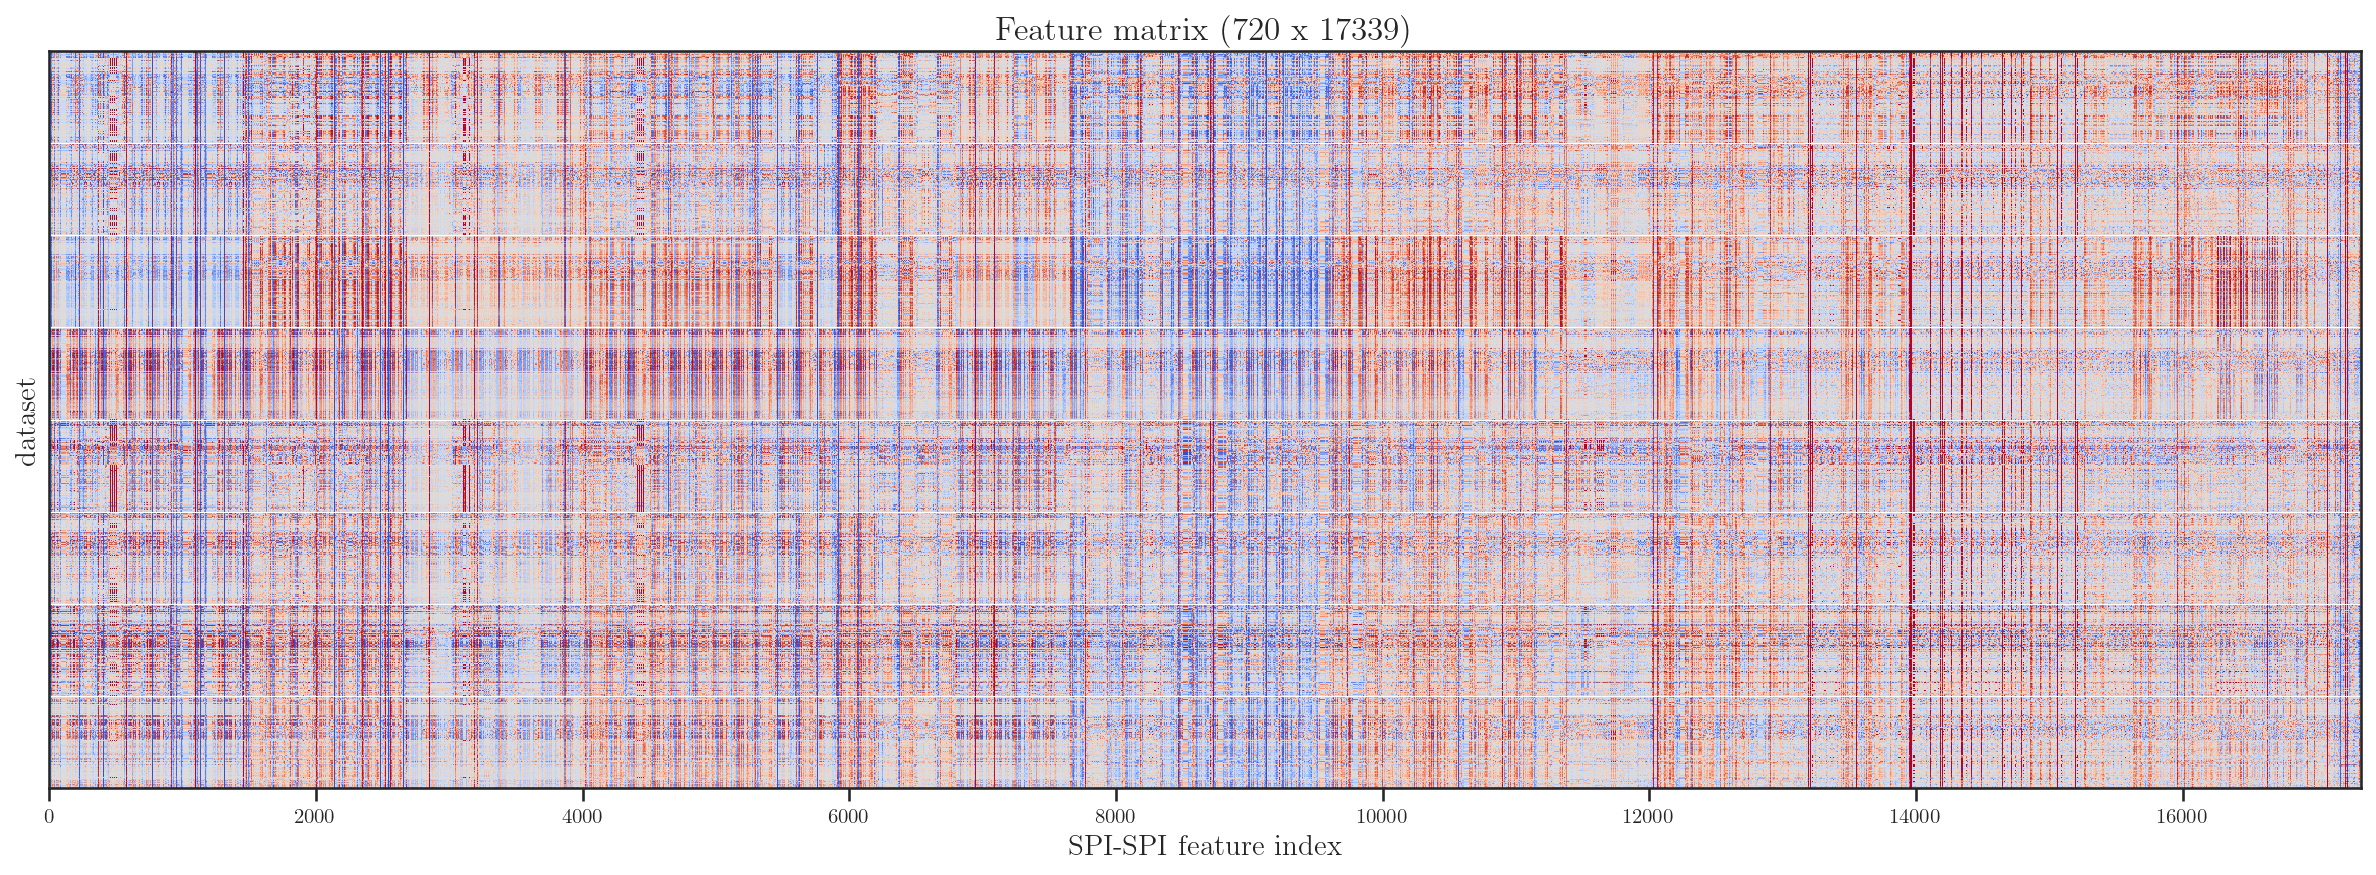

In [9]:
import seaborn as sns

# sort rows by class so blocks are visible
order = np.argsort(y)
X_sorted = X[order]
y_sorted = y[order]

fig, ax = plt.subplots(figsize=(16, 6), dpi=150)
ax.imshow(X_sorted, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1, interpolation="none")
ax.set_xlabel("SPI-SPI feature index")
ax.set_ylabel("dataset")
ax.set_yticks([])
ax.set_title(f"Feature matrix ({X_sorted.shape[0]} x {X_sorted.shape[1]})")

# class boundaries
boundaries = np.where(np.diff(np.searchsorted(np.unique(y_sorted), y_sorted)))[0] + 0.5
for b in boundaries:
    ax.axhline(b, color="white", linewidth=0.5)

plt.tight_layout()
plt.show()

/Users/wedi0306/Code/mts-spi-study-cluster/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/wedi0306/Code/mts-spi-study-cluster/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


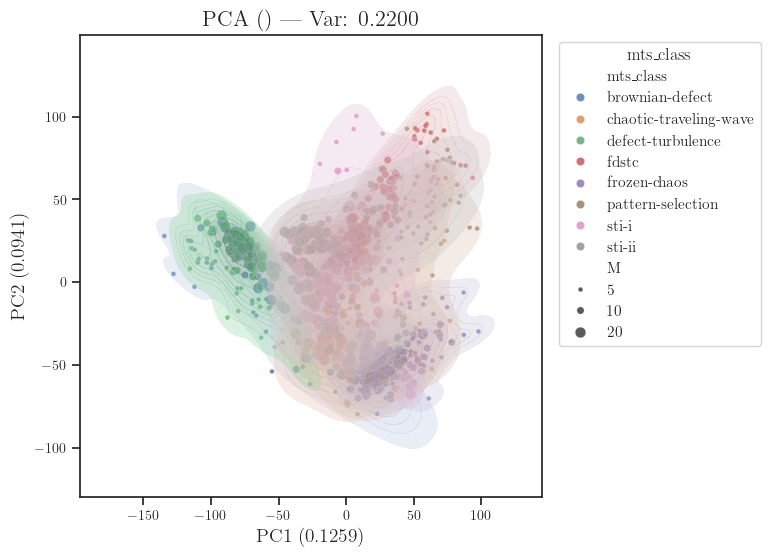

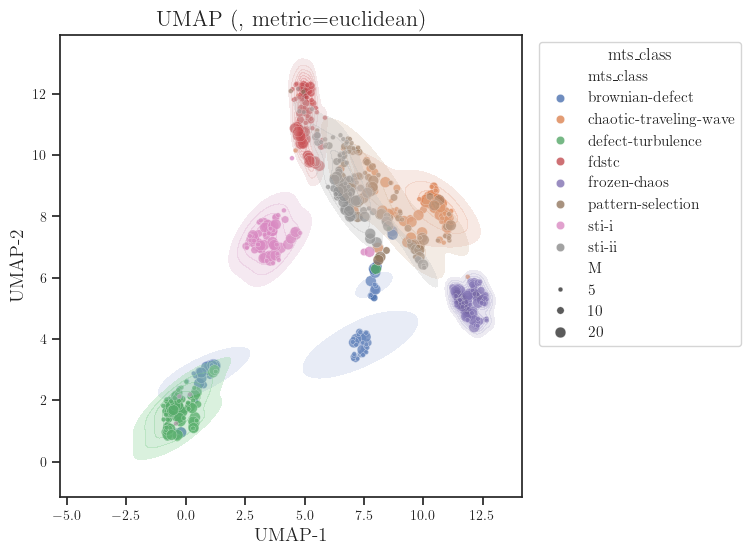

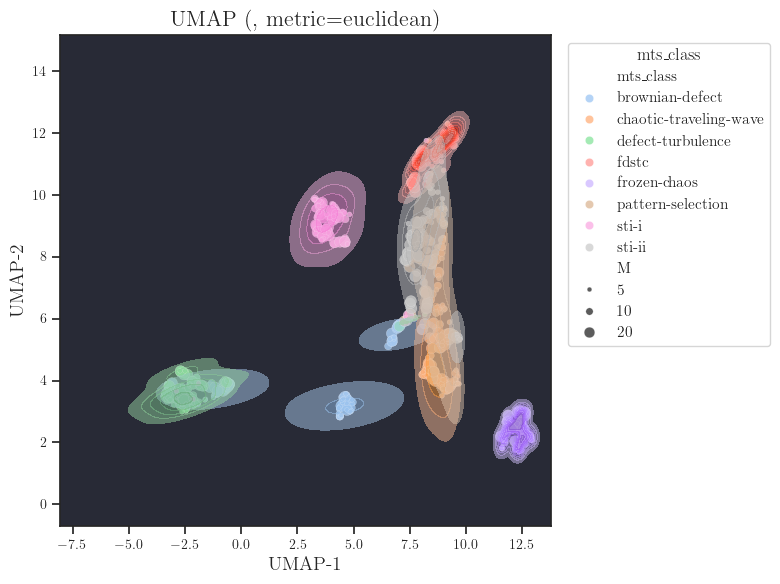

In [10]:
fig, ax1 = plt.subplots(1, 1, figsize=(18, 6))
plot_pca(X, meta_df, ax=ax1, kde=True)

fig, ax2 = plt.subplots(1, 1, figsize=(18,6))
plot_umap(X, meta_df,  ax=ax2, n_neighbors=9, min_dist=0.1, kde=True)

fig, ax3 = plt.subplots(1, 1, figsize=(18,6))
plot_umap_dark(X, meta_df, ax=ax3, n_neighbors=9, min_dist=0.05, kde=True)

plt.tight_layout(); plt.show()


